# Notebook 4 — Financial Commitment vs Engagement
**European Bank Customer Churn Analysis**

> Cross-analyse balance versus activity, detect salary–balance mismatches, and identify at-risk premium customers.

---

## Setup & Data Load

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F7',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid':        True,
    'grid.color':       '#E8E6DE',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

PALETTE = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'amber':  '#EF9F27',
    'coral':  '#D85A30',
    'purple': '#7F77DD',
    'red':    '#E24B4A',
    'gray':   '#888780',
    'green':  '#639922',
    'pink':   '#D4537E',
}
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('European_Bank.csv')
churn_rate = df['Exited'].mean() * 100
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns  |  Churn rate: {churn_rate:.1f}%')

Loaded: 10,000 rows × 14 columns  |  Churn rate: 20.4%


In [3]:
# ── Pre-compute shared fields ──────────────────────────────────────────────
HIGH_BALANCE_THRESHOLD = df['Balance'].quantile(0.75)
BALANCE_THRESHOLD      = df[df['Balance'] > 0]['Balance'].median()

# Engagement profile
def classify_engagement(row):
    active   = row['IsActiveMember'] == 1
    multi    = row['NumOfProducts']  >= 2
    high_bal = row['Balance'] >= HIGH_BALANCE_THRESHOLD and row['Balance'] > 0
    if active and multi:               return 'Active Engaged'
    elif not active and not multi and row['Balance'] == 0: return 'Inactive Disengaged'
    elif active and not multi:         return 'Active Low-Product'
    elif not active and high_bal:      return 'Inactive High-Balance'
    else:                              return 'Mixed'

df['EngagementProfile']    = df.apply(classify_engagement, axis=1)
df['ProductTier']          = df['NumOfProducts'].apply(
    lambda x: 'Single (1)' if x == 1 else ('Dual (2)' if x == 2 else 'Power (3-4)'))

salary_75  = df['EstimatedSalary'].quantile(0.75)
balance_25 = df[df['Balance'] > 0]['Balance'].quantile(0.25)
df['SalaryBalanceMismatch'] = (
    (df['EstimatedSalary'] >= salary_75) &
    ((df['Balance'] == 0) | (df['Balance'] < balance_25))
)
bal_75 = df['Balance'].quantile(0.75)
sal_75 = df['EstimatedSalary'].quantile(0.75)
df['IsPremium']       = (df['Balance'] >= bal_75) & (df['EstimatedSalary'] >= sal_75)
df['IsAtRiskPremium'] = df['IsPremium'] & (df['IsActiveMember'] == 0)

def sticky_score(row):
    s = 0
    if row['IsActiveMember'] == 1:        s += 2
    if row['NumOfProducts'] >= 2:          s += 2
    if row['HasCrCard'] == 1:              s += 1
    if row['Balance'] > BALANCE_THRESHOLD: s += 2
    if row['Tenure'] >= 5:                 s += 1
    if row['CreditScore'] >= 700:          s += 1
    return s
df['StickyScore'] = df.apply(sticky_score, axis=1)
df['StickyTier']  = pd.cut(df['StickyScore'], bins=[-1,2,5,7,9],
    labels=['Low (0-2)','Medium (3-5)','High (6-7)','Very High (8-9)'])

print('Shared features computed ✓')

Shared features computed ✓


## 4.1 — Balance vs Activity Cross-Analysis

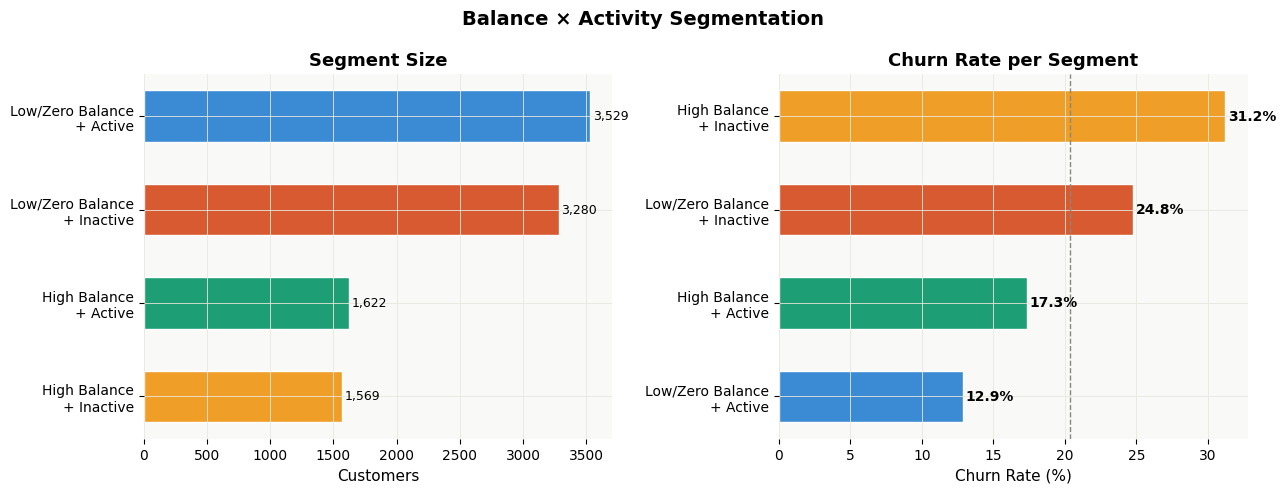


Balance threshold (median non-zero): £119,840


In [4]:
def balance_activity_segment(row):
    has_balance = row['Balance'] > BALANCE_THRESHOLD
    is_active   = row['IsActiveMember'] == 1
    if has_balance and is_active:         return 'High Balance\n+ Active'
    elif has_balance and not is_active:   return 'High Balance\n+ Inactive'
    elif not has_balance and is_active:   return 'Low/Zero Balance\n+ Active'
    else:                                 return 'Low/Zero Balance\n+ Inactive'

df['BalanceActivitySeg'] = df.apply(balance_activity_segment, axis=1)

seg_stats = df.groupby('BalanceActivitySeg').agg(
    Count       = ('Exited', 'count'),
    Churn_Rate  = ('Exited', 'mean'),
    Avg_Salary  = ('EstimatedSalary', 'mean'),
    Avg_Balance = ('Balance', 'mean')
).reset_index()
seg_stats['Churn_Pct'] = seg_stats['Churn_Rate'] * 100

seg_colors = [PALETTE['teal'], PALETTE['amber'], PALETTE['blue'], PALETTE['coral']]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Balance × Activity Segmentation', fontweight='bold', fontsize=14)

seg_sorted  = seg_stats.sort_values('Count', ascending=True)
c_sorted    = [seg_colors[list(seg_stats['BalanceActivitySeg']).index(x)] for x in seg_sorted['BalanceActivitySeg']]
axes[0].barh(seg_sorted['BalanceActivitySeg'], seg_sorted['Count'],
             color=c_sorted, height=0.55, edgecolor='white')
axes[0].set_title('Segment Size'); axes[0].set_xlabel('Customers')
for i,(_, row) in enumerate(seg_sorted.iterrows()):
    axes[0].text(row['Count']+20, i, f"{row['Count']:,}", va='center', fontsize=9)

seg_cr  = seg_stats.sort_values('Churn_Pct', ascending=True)
c_cr    = [seg_colors[list(seg_stats['BalanceActivitySeg']).index(x)] for x in seg_cr['BalanceActivitySeg']]
axes[1].barh(seg_cr['BalanceActivitySeg'], seg_cr['Churn_Pct'],
             color=c_cr, height=0.55, edgecolor='white')
axes[1].axvline(churn_rate, color=PALETTE['gray'], linestyle='--', linewidth=1)
axes[1].set_title('Churn Rate per Segment'); axes[1].set_xlabel('Churn Rate (%)')
for i,(_, row) in enumerate(seg_cr.iterrows()):
    axes[1].text(row['Churn_Pct']+0.2, i,
                 f"{row['Churn_Pct']:.1f}%", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_08_balance_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nBalance threshold (median non-zero): £{BALANCE_THRESHOLD:,.0f}')

## 4.2 — Salary–Balance Mismatch Detection

Salary-Balance Mismatch Detection
─────────────────────────────────────────────
  Definition     : Top-25% salary + bottom-25% balance
  Salary cutoff  : £149,388
  Balance cutoff : £100,182
  Customers flagged  : 1,285  (12.8%)
  Churn — mismatch   : 17.4%
  Churn — normal     : 20.8%
  Delta              : +-3.4 pp


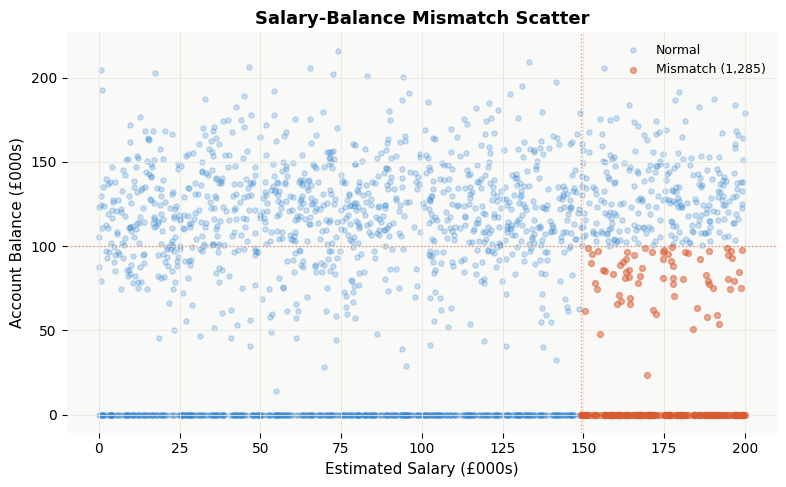

In [5]:
mismatch_count = df['SalaryBalanceMismatch'].sum()
mismatch_churn = df[df['SalaryBalanceMismatch']]['Exited'].mean() * 100
normal_churn   = df[~df['SalaryBalanceMismatch']]['Exited'].mean() * 100
salary_75_val  = df['EstimatedSalary'].quantile(0.75)
balance_25_val = df[df['Balance'] > 0]['Balance'].quantile(0.25)

print('Salary-Balance Mismatch Detection')
print('─' * 45)
print(f'  Definition     : Top-25% salary + bottom-25% balance')
print(f'  Salary cutoff  : £{salary_75_val:,.0f}')
print(f'  Balance cutoff : £{balance_25_val:,.0f}')
print(f'  Customers flagged  : {mismatch_count:,}  ({mismatch_count/len(df)*100:.1f}%)')
print(f'  Churn — mismatch   : {mismatch_churn:.1f}%')
print(f'  Churn — normal     : {normal_churn:.1f}%')
print(f'  Delta              : +{mismatch_churn - normal_churn:.1f} pp')

fig, ax = plt.subplots(figsize=(8, 5))
sample = df.sample(2000, random_state=42)
mis = sample[sample['SalaryBalanceMismatch']]
nom = sample[~sample['SalaryBalanceMismatch']]
ax.scatter(nom['EstimatedSalary']/1000, nom['Balance']/1000,
           alpha=0.25, s=14, color=PALETTE['blue'], label='Normal')
ax.scatter(mis['EstimatedSalary']/1000, mis['Balance']/1000,
           alpha=0.5, s=18, color=PALETTE['coral'],
           label=f'Mismatch ({mismatch_count:,})', zorder=5)
ax.axvline(salary_75_val/1000,  color=PALETTE['coral'], linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(balance_25_val/1000, color=PALETTE['coral'], linestyle=':', linewidth=1, alpha=0.6)
ax.set_xlabel('Estimated Salary (£000s)'); ax.set_ylabel('Account Balance (£000s)')
ax.set_title('Salary-Balance Mismatch Scatter', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('fig_09_salary_balance_mismatch.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 — At-Risk Premium Customers

At-Risk Premium Customer Analysis
──────────────────────────────────────────────────
  Premium def: Top-25% balance (≥£127,644) & salary (≥£149,388)
  Total premium customers    : 649
  At-risk premium (inactive) : 324
  Churn rate — at-risk       : 32.1%
  Total balance at risk      : £48,180,455
  Avg balance per at-risk    : £148,705


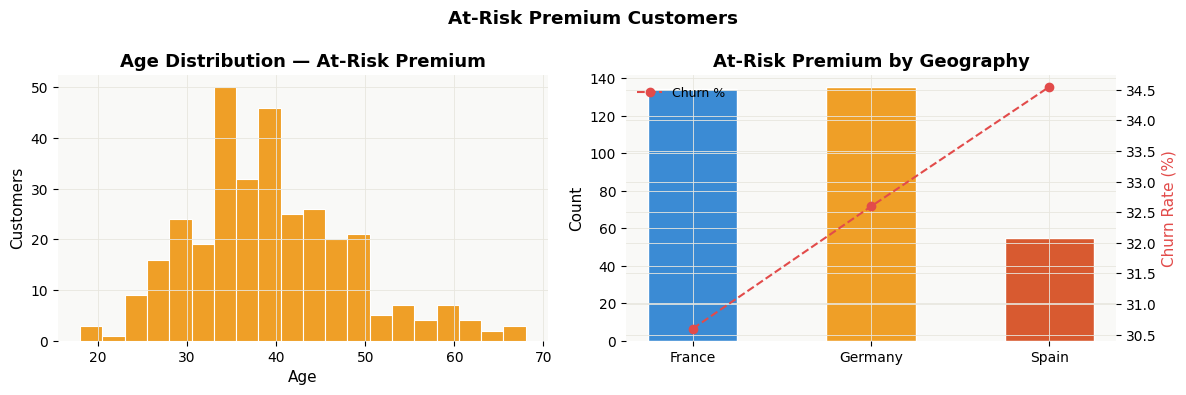

In [6]:
at_risk_count        = df['IsAtRiskPremium'].sum()
at_risk_churn        = df[df['IsAtRiskPremium']]['Exited'].mean() * 100
at_risk_balance_val  = df[df['IsAtRiskPremium']]['Balance'].sum()

print('At-Risk Premium Customer Analysis')
print('─' * 50)
print(f'  Premium def: Top-25% balance (≥£{bal_75:,.0f}) & salary (≥£{sal_75:,.0f})')
print(f'  Total premium customers    : {df["IsPremium"].sum():,}')
print(f'  At-risk premium (inactive) : {at_risk_count:,}')
print(f'  Churn rate — at-risk       : {at_risk_churn:.1f}%')
print(f'  Total balance at risk      : £{at_risk_balance_val:,.0f}')
print(f'  Avg balance per at-risk    : £{df[df["IsAtRiskPremium"]]["Balance"].mean():,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('At-Risk Premium Customers', fontweight='bold')

axes[0].hist(df[df['IsAtRiskPremium']]['Age'], bins=20,
             color=PALETTE['amber'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Age Distribution — At-Risk Premium')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Customers')

geo_ar = df[df['IsAtRiskPremium']].groupby('Geography').agg(
    Count=('Exited','count'), Churn_Rate=('Exited','mean')).reset_index()
geo_ar['Churn_Pct'] = geo_ar['Churn_Rate'] * 100
axes[1].bar(geo_ar['Geography'], geo_ar['Count'],
            color=[PALETTE['blue'], PALETTE['amber'], PALETTE['coral']],
            edgecolor='white', width=0.5)
ax2b = axes[1].twinx()
ax2b.plot(geo_ar['Geography'], geo_ar['Churn_Pct'],
          'o--', color=PALETTE['red'], linewidth=1.5, markersize=6, label='Churn %')
axes[1].set_title('At-Risk Premium by Geography')
axes[1].set_ylabel('Count'); ax2b.set_ylabel('Churn Rate (%)', color=PALETTE['red'])
ax2b.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('fig_10_at_risk_premium.png', dpi=150, bbox_inches='tight')
plt.show()